<a href="https://colab.research.google.com/github/Ademola-Olorunnisola/Nonlinear_and_Data_Driven_Estimation/blob/main/Ademola%20nonlinear%20EKF%20UKF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy.integrate import odeint
import scipy.optimize

import sympy as sp

import pandas as pd

from scipy.integrate import odeint
import copy

In [2]:

try:
    import casadi
except:
    !pip install casadi
    import casadi

try:
    import do_mpc
except:
    !pip install do_mpc
    import do_mpc

try:
    import pybounds
except:
    #!pip install pybounds
    !pip install git+https://github.com/vanbreugel-lab/pybounds
    import pybounds

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 3.8 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/do_mpc/sysid/__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
/usr/local/lib/python3.12/dist-packages/do_mpc/opcua/__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')


  Cloning https://github.com/vanbreugel-lab/pybounds to /tmp/pip-req-build-tn814f6i
  Running command git clone --filter=blob:none --quiet https://github.com/vanbreugel-lab/pybounds /tmp/pip-req-build-tn814f6i
  Resolved https://github.com/vanbreugel-lab/pybounds to commit 96f12039ac9e1e3ef4381cd09a026f6bbf70ad5c
  Preparing metadata (setup.py) ... done
  Created wheel for pybounds: filename=pybounds-0.0.13-py3-none-any.whl size=19546 sha256=844499b959aa8a134ba98fb86e8ffe5867c736ab378e22967667533af47e52e0
  Stored in directory: /tmp/pip-ephem-wheel-cache-k2u9tcl9/wheels/cb/f8/fb/ff1887f9a2f35c3edad7b1acb7da69437c1fd8d885a800578d
Successfully built pybounds


In [3]:
import sys
import requests
import importlib

def import_local_or_github(package_name, function_name=None, directory=None, giturl=None):
    # Import functions directly from github
    # Important: note that we use raw.githubusercontent.com, not github.com

    try: # to find the file locally
        if directory is not None:
            if directory not in sys.path:
                sys.path.append(directory)

        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package, function_name)
            return function
        else:
            return package

    except: # get the file from github
        if giturl is None:
            giturl = 'https://raw.githubusercontent.com/Ademola-Olorunnisola/Nonlinear_and_Data_Driven_Estimation/main/Utility/' + str(package_name) + '.py'

        r = requests.get(giturl)
        print('Fetching from: ')
        print(r)

        # Store the file to the colab working directory
        with open(package_name+'.py', 'w') as f:
            f.write(r.text)
        f.close()

        # import the function we want from that file
        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package , function_name)
            return function
        else:
            return package

tb_simulations = import_local_or_github('tb_simulations', directory='../Utility')
plot_tme = import_local_or_github('plot_utility', 'plot_tme', directory='../Utility')
extended_kalman_filter = import_local_or_github('extended_kalman_filter', directory='../Utility')
unscented_kalman_filter = import_local_or_github('unscented_kalman_filter', directory='../Utility')

Fetching from: 
<Response [200]>
Fetching from: 
<Response [200]>
Fetching from: 
<Response [200]>
Fetching from: 
<Response [200]>


$$
\mathbf{\dot{x}} = \mathbf{f}(\mathbf{x},\mathbf{u}) = \mathbf{f_0}(\mathbf{x}) + \mathbf{f_1}(\mathbf{x})\bbox[lightgreen]{\alpha} + \mathbf{f_2}(\mathbf{x})\bbox[lightgreen]{\kappa}
$$

$$
\frac{d}{dt}
\begin{bmatrix}
\bbox[yellow]{S} \\[0.3em]
\bbox[yellow]{V} \\[0.3em]
\bbox[yellow]{I} \\[0.3em]
\bbox[yellow]{R} \\[0.3em]
\bbox[pink]{\beta} \\[0.3em]
\bbox[pink]{\sigma}
\end{bmatrix} =
\overset{f_0}{\begin{bmatrix}
\bbox[lightblue]{\Lambda} - \bbox[pink]{\beta}\bbox[yellow]{SI} - \bbox[lightblue]{\mu}\bbox[yellow]{S} \\[0.3em]
0 - \bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} - \bbox[lightblue]{\mu}\bbox[yellow]{V} \\[0.3em]
\bbox[pink]{\beta}\bbox[yellow]{SI} + \bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} - \bbox[lightblue]{\gamma}\bbox[yellow]{I} - \bbox[lightblue]{\mu}\bbox[yellow]{I} \\[0.3em]
\bbox[lightblue]{\gamma}\bbox[yellow]{I} - \bbox[lightblue]{\mu}\bbox[yellow]{R}\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} +
\overset{f_1}{\begin{bmatrix}
-\bbox[yellow]{S} \\[0.3em]
\bbox[yellow]{S} \\[0.3em]
0 \\[0.3em]
0\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} \bbox[lightgreen]{\alpha} +
\overset{f_2}{\begin{bmatrix}
\bbox[pink]{\beta}\bbox[yellow]{SI} \\[0.3em]
\bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} \\[0.3em]
-\bbox[pink]{\beta}\bbox[yellow]{SI} - \bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} \\[0.3em]
0\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} \bbox[lightgreen]{\kappa}
$$

# Dynamics and measurement functions

In [4]:
h_a = tb_simulations.H('h_ivr').h
h_b = tb_simulations.H('h_all_svir').h



In [5]:
def h_corrected(x_vec, u_vec, return_measurement_names=False):
    """
    Measurement function accounting for 60% reporting
    Returns: [V, I_reported, R] to match y_noisy_df column order
    """
    if return_measurement_names:
        return ['V_absolute', 'I_reported', 'R_absolute']

    # Extract states
    V = x_vec[1]
    I = x_vec[2]
    R = x_vec[3]

    # Apply 60% reporting to infections
    I_reported = 0.60 * I

    # Return in same order as your data: [V, I_reported, R]
    return np.array([V, I_reported, R])

In [6]:
f = tb_simulations.F().f
h = h_corrected

In [7]:
h(None, None, return_measurement_names=True)

['V_absolute', 'I_reported', 'R_absolute']

In [8]:
def u_func(x_vec, t):
    """Simple vaccination and social distancing controller"""
    I = x_vec[2]
    I_threshold = 0.005
    alpha = 0.01 if I > I_threshold else 0.005
    kappa = 0.3 if I > I_threshold else 0.1
    return np.array([alpha, kappa])

In [9]:
def f_ode(x_vec, t):
    """Wrapper for odeint"""
    u_vec = u_func(x_vec, t)
    return f(x_vec, u_vec)


In [10]:
N = 223000000

# TRUE initial conditions
x0_true = np.array([
    52309000/N,
    158330000/N,
    361000/N,
    12000000/N,
    0.00003,
    0.85
])

# FILTER INITIAL GUESS
x0_filter = np.array([
    60000000/N,
    145000000/N,
    500000/N,
    17500000/N,
    0.00005,
    0.70
])

# Run simulation

In [11]:
t_sim = np.arange(0, 365, 1.0)
result = odeint(f_ode, x0_true, t_sim)

In [12]:
x_sim = {
    'S': result[:, 0],
    'V': result[:, 1],
    'I': result[:, 2],
    'R': result[:, 3],
    'beta': result[:, 4],
    'sigma': result[:, 5]
}

In [13]:
u_sim = {'alpha': [], 'kappa': []}
for i in range(len(t_sim)):
    u = u_func(result[i], t_sim[i])
    u_sim['alpha'].append(u[0])
    u_sim['kappa'].append(u[1])

In [14]:
REPORTING_RATE = 0.60

In [15]:
y_true_absolute = {
    'S_absolute': x_sim['S'] * N,
    'V_absolute': x_sim['V'] * N,
    'I_absolute': x_sim['I'] * N,
    'R_absolute': x_sim['R'] * N
}


# Simulate noisy measurements

In [16]:
measurement_noise_stds = {
    'V_absolute': 2000000.0,
    'I_absolute': 30000.0,
    'R_absolute': 500000.0
}


In [17]:
np.random.seed(42)
y_noisy_absolute = {}
y_noisy_absolute['S_absolute'] = np.full(len(t_sim), np.nan)

In [18]:
y_noisy_absolute['V_absolute'] = (
    y_true_absolute['V_absolute'] +
    np.random.normal(0, measurement_noise_stds['V_absolute'], len(t_sim))
)

y_noisy_absolute['I_absolute'] = np.maximum(
    y_true_absolute['I_absolute'] * REPORTING_RATE +
    np.random.normal(0, measurement_noise_stds['I_absolute'], len(t_sim)),
    0
)

y_noisy_absolute['R_absolute'] = (
    y_true_absolute['R_absolute'] +
    np.random.normal(0, measurement_noise_stds['R_absolute'], len(t_sim))
)


In [19]:
y_noisy = {key: y_noisy_absolute[key] / N for key in y_noisy_absolute.keys()}

<Axes: xlabel='Time', ylabel='R_absolute'>

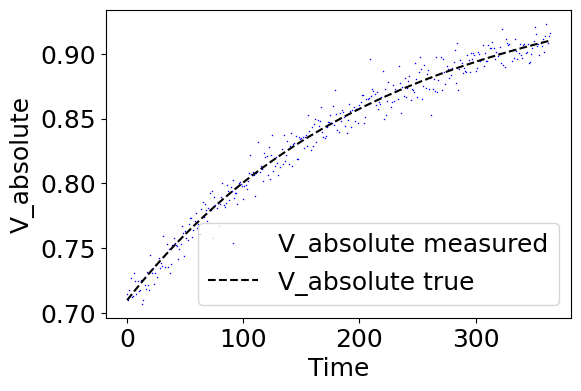

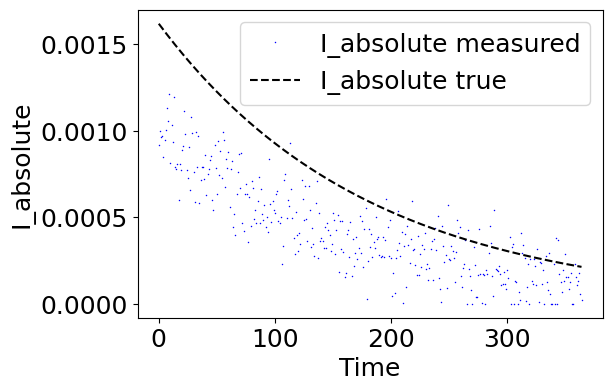

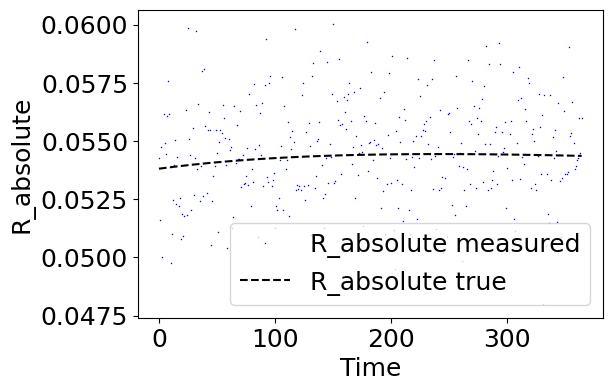

In [20]:
plot_tme(t_sim, x_sim['V'], y_noisy['V_absolute'], label_var='V_absolute')
plot_tme(t_sim, x_sim['I'], y_noisy['I_absolute'], label_var='I_absolute')
plot_tme(t_sim, x_sim['R'], y_noisy['R_absolute'], label_var='R_absolute')

### Save data as dataframes

In [21]:
y_noisy_df = pd.DataFrame({
    'V_absolute': y_noisy['V_absolute'],
    'I_reported': y_noisy['I_absolute'],  # This is already underreported
    'R_absolute': y_noisy['R_absolute']
})
u_sim_df = pd.DataFrame(u_sim)
u0 = np.array([u_sim['alpha'][0], u_sim['kappa'][0]])

# Kalman filter parameters and initilization

In [22]:
x0_filter[4] = 0.00003

In [23]:
P0 = np.diag([
    0.01,
    0.01,
    0.002,
    0.02,
    0.00001,
    0.05
])

Q = np.diag([
    1e-4,      # S
    1e-4,      # V
    1e-5,      # I
    1e-4,      # R
    1e-7,      # beta - increase from 1e-8 to 1e-7 (10x more)
    1e-7        # sigma
])

R_stds = np.array([
    measurement_noise_stds['V_absolute'] / N,
    measurement_noise_stds['I_absolute'] / N,
    measurement_noise_stds['R_absolute'] / N
])
R = np.diag(R_stds**2)

# Extended Kalman Filter

In [24]:
EKF = extended_kalman_filter.EKF(
    f, h, x0_filter, u0, P0, Q, R,
    dynamics_type='continuous',
    discretization_timestep=1.0,
    circular_measurements=(0, 0, 0)
)

In [25]:
EKF.estimate(y_noisy_df, u_sim_df)

In [26]:
EKF.history.keys()

dict_keys(['X', 'U', 'Z', 'P', 'P_diags', 'R', 'Q', 'F', 'H', 'S', 'K', 'E', 'rho', 'Jk', 'inv_Jk'])

In [27]:
# State estimate
x_est = pd.DataFrame(np.vstack(EKF.history['X']), columns=f(None,None,return_state_names=True))

In [28]:
# Covariance diagonals
P_diags = np.vstack([np.diag(EKF.history['P'][i]) for i in range(len(EKF.history['P']))])
P_diags = pd.DataFrame(P_diags, columns=f(None,None,return_state_names=True))

## Plots

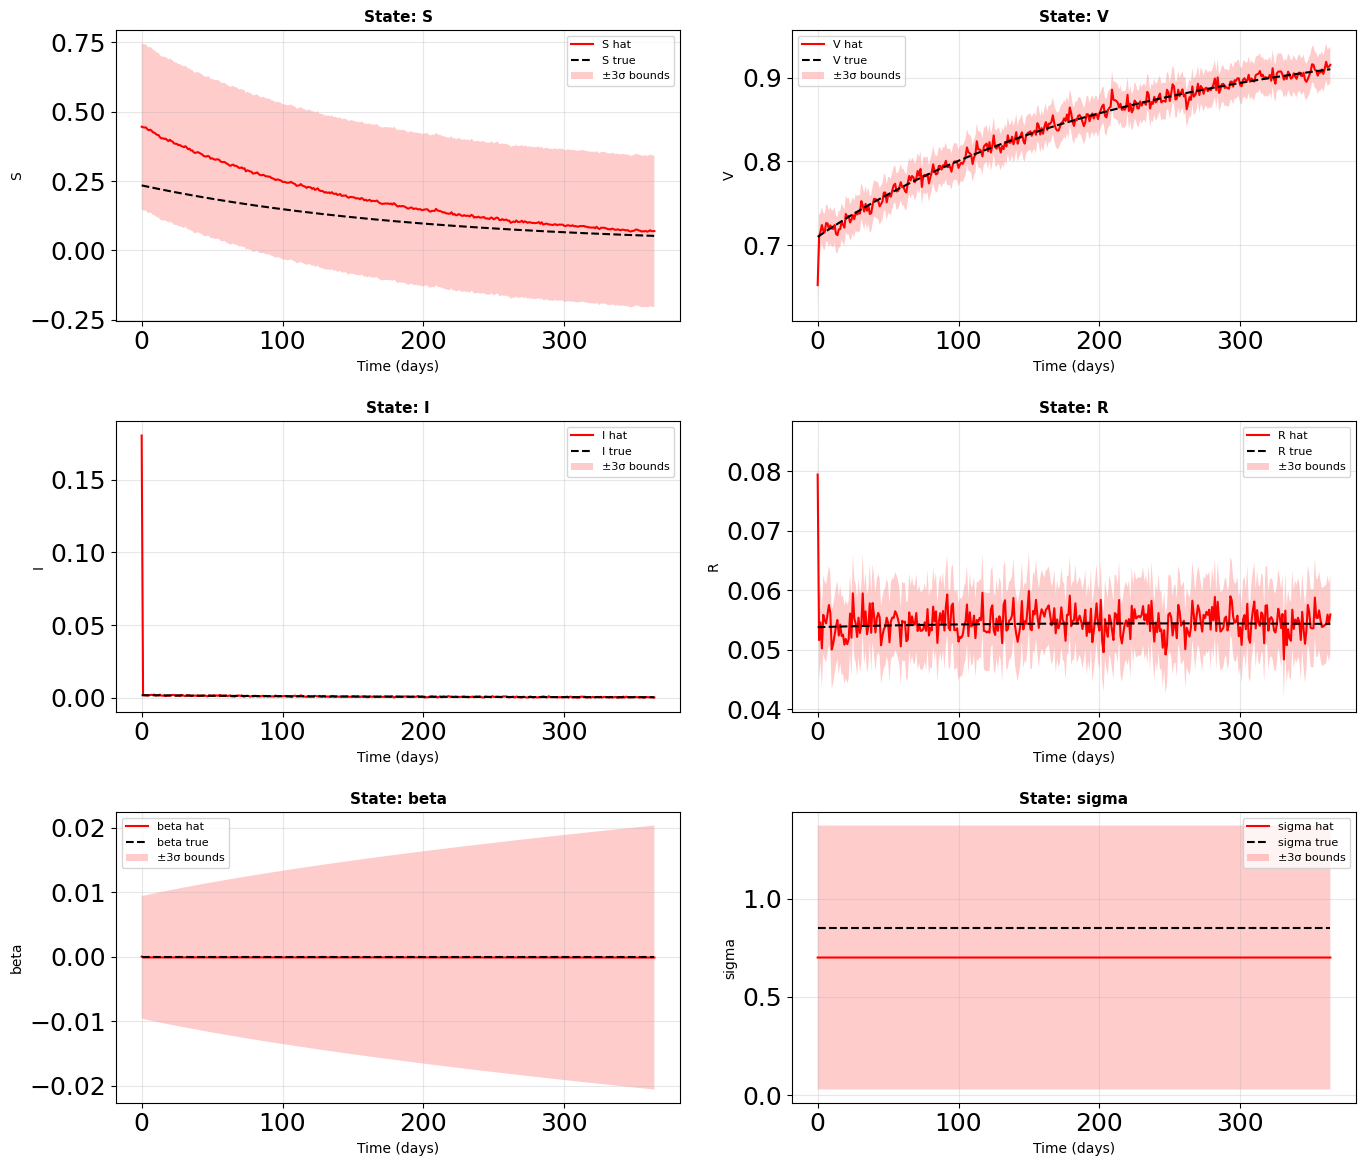

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Get state names
state_names = f(None, None, return_state_names=True)
n_states = len(state_names)

# Create subplots - 3 rows x 2 columns for 6 states
fig, axes = plt.subplots(3, 2, figsize=(14, 12), dpi=100)
axes = axes.flatten()  # Flatten to 1D array for easy indexing

# Convert to numpy arrays once
x_est_array = np.array(x_est)
P_diags_array = np.array(P_diags)

# Plot each state
for i, state in enumerate(state_names):
    ax = axes[i]

    # Extract columns for this state
    x_est_col = x_est_array[:, i]
    P_diag_col = P_diags_array[:, i]

    # Plot true trajectory, measurements (if available), and estimate
    if state in y_noisy.keys():
        # If we have measurements for this state
        plot_tme(t_sim, x_sim[state], y_noisy[state], x_est_col,
                label_var=state, ax=ax)
    else:
        # No measurements for this state (e.g., beta, sigma)
        plot_tme(t_sim, x_sim[state], None, x_est_col,
                label_var=state, ax=ax)

    # Add 3-sigma uncertainty bounds
    plus_3sigma = x_est_col + 3*np.sqrt(P_diag_col)
    minus_3sigma = x_est_col - 3*np.sqrt(P_diag_col)
    ax.fill_between(t_sim, plus_3sigma, minus_3sigma,
                    facecolor='red', edgecolor='none', alpha=0.2,
                    label='±3σ bounds')

    # Formatting
    ax.set_xlabel('Time (days)', fontsize=10)
    ax.set_ylabel(f'{state}', fontsize=10)
    ax.set_title(f'State: {state}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


# Unscented Kalman Filter

In [30]:
UKF = unscented_kalman_filter.UKF(
    f, h, x0_filter, u0, P0, Q, R,
    dynamics_type='continuous',
    discretization_timestep=1.0,
    alpha=0.1
)

In [31]:
UKF.estimate(y_noisy_df, u_sim_df)

In [32]:
UKF.history.keys()

dict_keys(['X', 'P', 'P_diags', 'sigma_points'])

In [33]:
# State estimate
x_est = pd.DataFrame(np.vstack(UKF.history['X']), columns=f(None,None,return_state_names=True))

In [34]:
# Covariance diagonals
P_diags = np.vstack([np.diag(UKF.history['P'][i]) for i in range(len(UKF.history['P']))])
P_diags = pd.DataFrame(P_diags, columns=f(None,None,return_state_names=True))

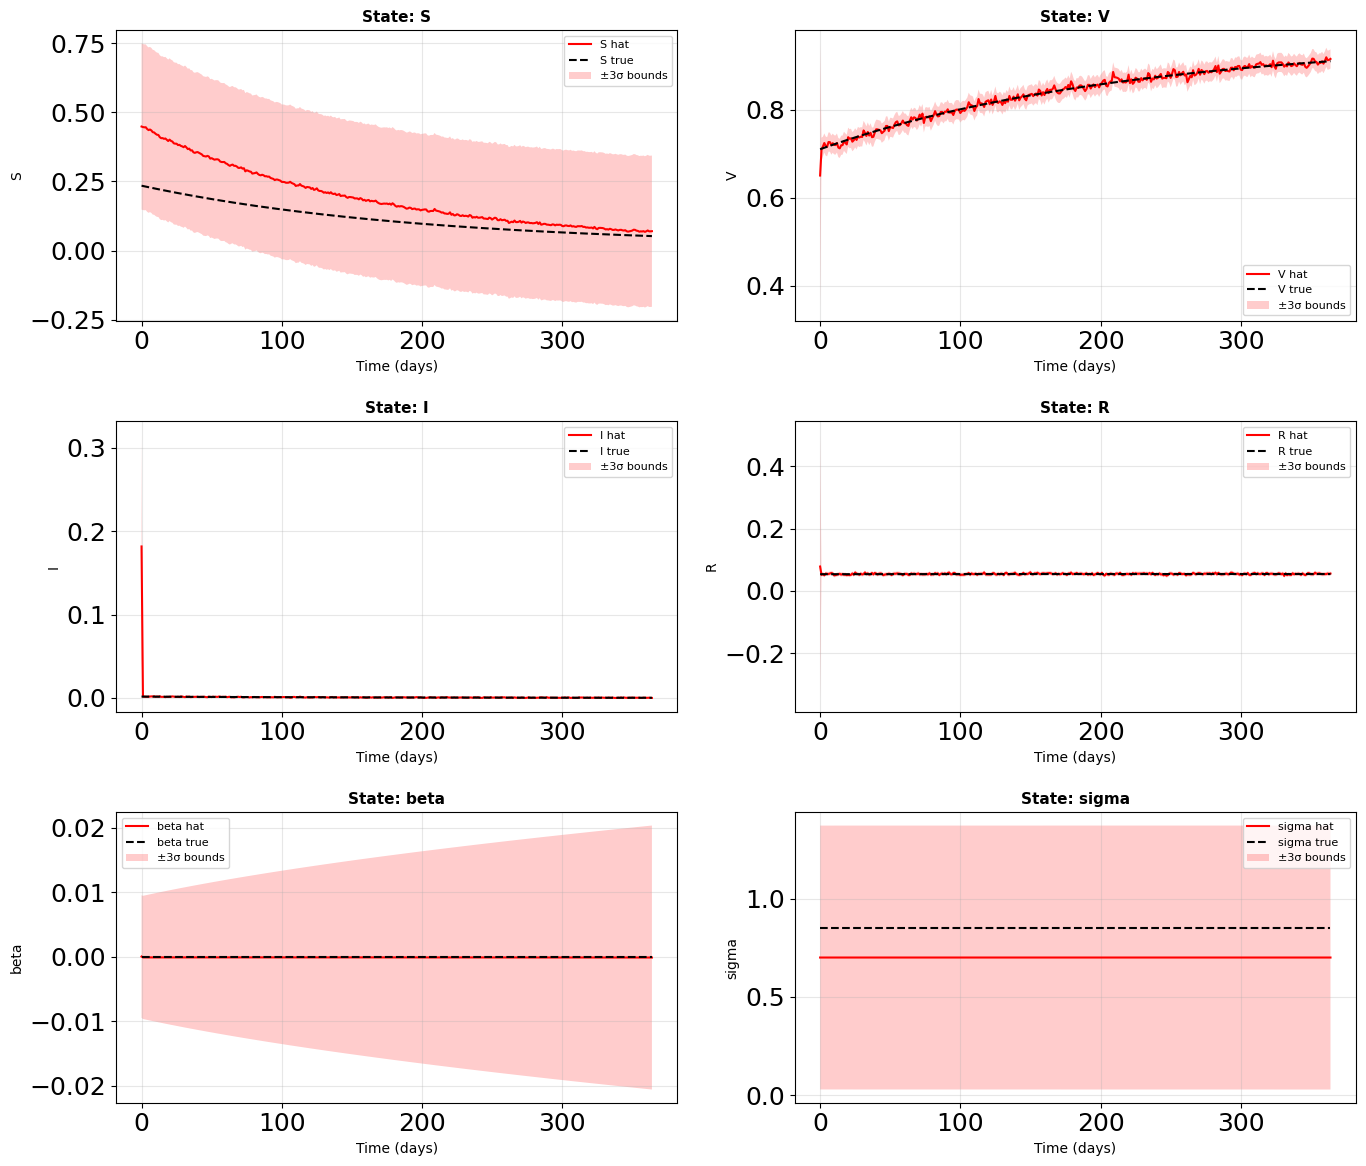

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Get state names
state_names = f(None, None, return_state_names=True)
n_states = len(state_names)

# Create subplots - 3 rows x 2 columns for 6 states
fig, axes = plt.subplots(3, 2, figsize=(14, 12), dpi=100)
axes = axes.flatten()  # Flatten to 1D array for easy indexing

# Convert to numpy arrays once
x_est_array = np.array(x_est)
P_diags_array = np.array(P_diags)

# Plot each state
for i, state in enumerate(state_names):
    ax = axes[i]

    # Extract columns for this state
    x_est_col = x_est_array[:, i]
    P_diag_col = P_diags_array[:, i]

    # Plot true trajectory, measurements (if available), and estimate
    if state in y_noisy.keys():
        # If we have measurements for this state
        plot_tme(t_sim, x_sim[state], y_noisy[state], x_est_col,
                label_var=state, ax=ax)
    else:
        # No measurements for this state (e.g., beta, sigma)
        plot_tme(t_sim, x_sim[state], None, x_est_col,
                label_var=state, ax=ax)

    # Add 3-sigma uncertainty bounds
    plus_3sigma = x_est_col + 3*np.sqrt(P_diag_col)
    minus_3sigma = x_est_col - 3*np.sqrt(P_diag_col)
    ax.fill_between(t_sim, plus_3sigma, minus_3sigma,
                    facecolor='red', edgecolor='none', alpha=0.2,
                    label='±3σ bounds')

    # Formatting
    ax.set_xlabel('Time (days)', fontsize=10)
    ax.set_ylabel(f'{state}', fontsize=10)
    ax.set_title(f'State: {state}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
